# 09. Problem-site 데이터 진단 — 광양항세방 / 예천 / 창원

**배경**: ResMLP+AdaLN ensemble (5 seeds) test에서 site별 NMAE가 크게 갈렸다.

| 그룹 | 사이트 | 평균 NMAE |
|---|---|---|
| ✅ Good (5) | 경상대, 고흥만수상, 영흥, 삼천포, 구미 | 3.4 ~ 5.2% |
| ⚠️ Problem (3) | **광양항세방, 예천, 창원** | 8.1 ~ 8.6% |

**광양항세방**은 bias +7%로 강한 over-prediction. **예천**은 Cov80 78% (under-confident). **창원**은 NMAE 8.55%로 가장 큰데 Cov80 91%는 정상.

**목표**: 모델을 다시 바꾸기 전에 이 3 사이트가
1. 데이터 품질 문제 (clipping, flatline, capacity 잘못, 결측 다수)
2. 운영/설비 특성 (작은 사이트 / 노후 / shading)
3. 진짜 site-specific physical response (지형/microclimate)
중 무엇 때문인지 빠르게 판별.


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
import matplotlib as mpl, matplotlib.font_manager as fm
for f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
    if any(f.lower() in n.name.lower() for n in fm.fontManager.ttflist):
        mpl.rcParams['font.family'] = f; break
mpl.rcParams['axes.unicode_minus'] = False

ROOT = Path('../..').resolve()
df = pd.read_parquet(ROOT / 'data/processed/training_set.parquet')
print('shape:', df.shape, '| sites:', df.site.nunique())
print('date range:', df.datetime_kst.min(), '~', df.datetime_kst.max())
print('matplotlib font.family:', mpl.rcParams['font.family'])

PROBLEM = ['광양항세방', '예천', '창원']
GOOD    = ['경상대', '고흥만수상', '영흥', '삼천포', '구미']
ALL     = GOOD + PROBLEM
# 각 PROBLEM 사이트 다른 색 (광양항=빨강, 예천=주황, 창원=자주). GOOD 5개는 파랑 계열로 grouping.
COLOR = {
    '광양항세방': '#d62728',   # red
    '예천':       '#ff7f0e',   # orange
    '창원':       '#9467bd',   # purple
    '경상대':     '#1f77b4',   # blue
    '고흥만수상': '#2ca02c',   # green
    '영흥':       '#17becf',   # cyan
    '삼천포':     '#8c564b',   # brown
    '구미':       '#7f7f7f',   # gray
}

# 학습 가능 시간만 (낮 시간 + cf 존재)
df = df[df.dsr_mean.notna() & df.cf.notna()].copy()
df['hour']  = df.datetime_kst.dt.hour
df['month'] = df.datetime_kst.dt.month
print('\n학습 가능 행:', len(df), '| daytime')


shape: (265687, 27) | sites: 8
date range: 2022-01-01 10:00:00 ~ 2026-01-01 00:00:00
matplotlib font.family: ['Malgun Gothic']

학습 가능 행: 122974 | daytime


## 1. Capacity & cf 범위 — clipping / 정규화 이상 1차 점검

`cf = gen_kwh / site_capacity_kw`. 정상 PV는 cf ∈ [0, ~1.05] (clear-sky overirradiance 가능).

**판독 기준**:
- cf > 1.0 비율이 사이트별로 다르면 → 분모(설비용량) 잘못 입력 가능성
- cf의 99th percentile 차이가 크면 → 사이트별 *peak 운영* 다름 (clipping, derating)
- cf의 max 값 — 극값이 너무 크면 (>1.5) capacity 표기 오류 의심


In [ ]:
cap_summary = df.groupby('site')['site_capacity_kw'].first()
cf_q = df.groupby('site')['cf'].agg(['mean', 'std', 'min',
        lambda s: s.quantile(0.5),
        lambda s: s.quantile(0.95),
        lambda s: s.quantile(0.99),
        'max',
        lambda s: (s > 1.0).mean(),
        lambda s: (s > 0.0).mean()])
cf_q.columns = ['mean','std','min','p50','p95','p99','max','frac_gt1','frac_gt0']
cf_q = cf_q.join(cap_summary.rename('cap_kw'))
cf_q['group'] = cf_q.index.map(lambda s: 'PROBLEM' if s in PROBLEM else 'GOOD')
print(cf_q.loc[ALL].round(3).to_string())


        mean    std  min    p50    p95    p99    max  frac_gt1  frac_gt0  cap_kw    group
site                                                                                     
경상대    0.280  0.210  0.0  0.254  0.628  0.704  0.770       0.0     0.951     905     GOOD
고흥만수상  0.339  0.246  0.0  0.310  0.743  0.813  0.880       0.0     0.987   63481     GOOD
영흥     0.303  0.233  0.0  0.260  0.694  0.756  0.863       0.0     0.988    5493     GOOD
삼천포    0.294  0.231  0.0  0.255  0.693  0.766  0.851       0.0     0.985    1340     GOOD
구미     0.289  0.223  0.0  0.259  0.664  0.731  0.826       0.0     0.962     992     GOOD
광양항세방  0.256  0.201  0.0  0.211  0.614  0.687  0.801       0.0     0.960    2993  PROBLEM
예천     0.275  0.233  0.0  0.227  0.682  0.749  0.857       0.0     0.899    2000  PROBLEM
창원     0.257  0.212  0.0  0.201  0.665  0.762  1.263       0.0     0.970      77  PROBLEM


→ **모델 함의**:
- `frac_gt1` (cf>1 비율)이 PROBLEM 사이트에서 비정상적으로 높으면 → 분모(capacity) 오류 가능 → 모델이 unfit한 게 아니라 **타깃이 잘못 정규화된** 문제.
- `p99 / p95` 갭이 PROBLEM에서만 크면 → outlier/spike (인버터 오버슈팅, 이중 계측).
- `cap_kw` 자체가 다른 사이트의 1/10 수준이면 → 노이즈 우세 (작은 사이트일수록 단일 cell trip이 큰 비율).


## 2. cf 분포 histogram — clear-sky 영역과 0 근처 mass 비교

**판독 기준**:
- 0 근처 spike (밤이 아닌 낮 시간에) 큰 사이트 → flatline / 정지 / outage 흔함
- 0.8~1.0 영역의 mass — 정상 사이트는 clear-sky 정점 cf ≈ 0.8~1.0이 자주 등장
- 다중 mode → 사이트 내부 inverter group 별로 다른 동작 (예: 오프라인 1대 + 정상 1대)


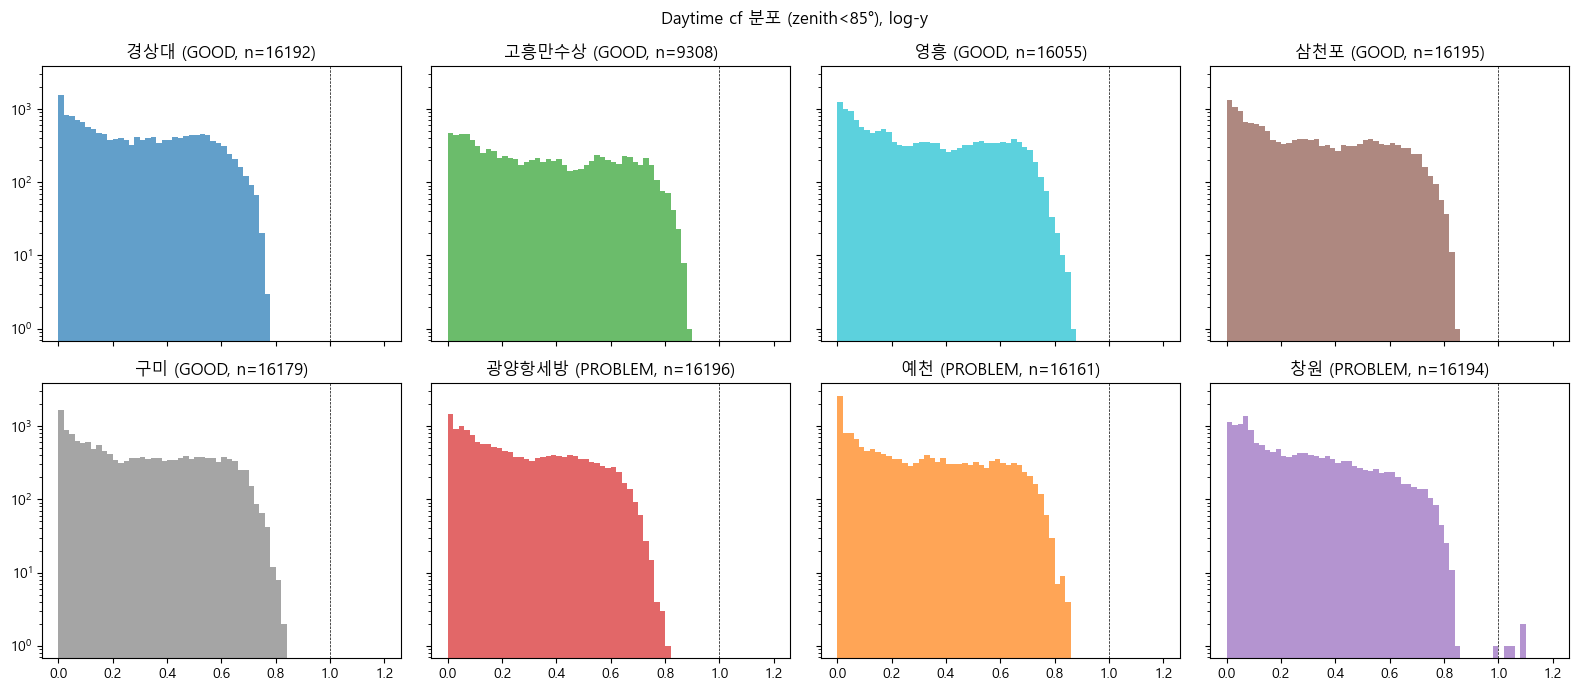

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()
# daytime only (zenith < 85 = sun above horizon)
day = df[df.zenith_center < 85].copy()
for ax, site in zip(axes, ALL):
    s = day[day.site == site]['cf'].values
    ax.hist(s, bins=60, range=(0, 1.2), color=COLOR[site], alpha=0.7)
    ax.axvline(1.0, color='k', lw=0.5, ls='--')
    grp = 'PROBLEM' if site in PROBLEM else 'GOOD'
    ax.set_title(f'{site} ({grp}, n={len(s)})')
    ax.set_yscale('log')
plt.suptitle('Daytime cf 분포 (zenith<85°), log-y')
plt.tight_layout()
plt.show()


→ **모델 함의**:
- 0 근처 mass가 PROBLEM에서 크면 → 모델이 학습한 "irradiance → cf" 관계가 outage 행에서 작동 안 함. **fixed-effect로 모델이 누락된 down event를 알 수 없음**.
- mode가 1.0 근처에 잘 형성되면 → 사이트 자체는 잘 작동, 모델이 못 잡는 부분이 따로 존재 (변동성 / shading).


## 3. 시간대별 평균 cf — 일주기 모양

**판독 기준**:
- 정상: bell-curve, 정점이 정오 직후 12~13시
- 비대칭(아침<오후 또는 반대): 동/서 향, 산 그림자
- 정점 낮음(0.4~0.5): 작은 사이트의 다수 panel offline 또는 capacity 입력 over-estimate


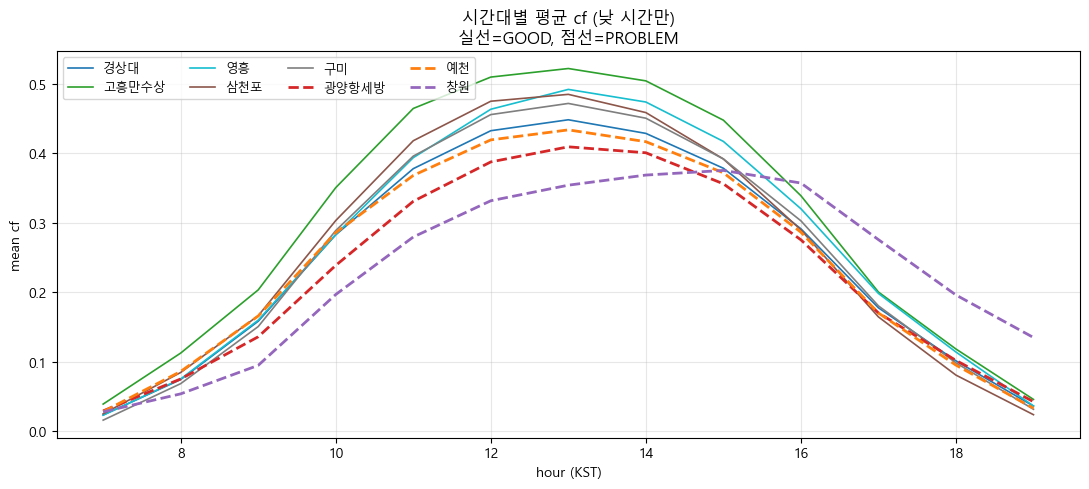

In [ ]:
hour_avg = df[df.zenith_center < 85].groupby(['site', 'hour'])['cf'].mean().unstack('site')
fig, ax = plt.subplots(figsize=(11, 5))
for site in ALL:
    ls = '--' if site in PROBLEM else '-'
    lw = 2.0 if site in PROBLEM else 1.2
    ax.plot(hour_avg.index, hour_avg[site], color=COLOR[site], ls=ls, lw=lw, label=site)
ax.set_xlabel('hour (KST)'); ax.set_ylabel('mean cf'); ax.grid(alpha=0.3)
ax.set_title('시간대별 평균 cf (낮 시간만)\n실선=GOOD, 점선=PROBLEM')
ax.legend(ncol=4, fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()


→ **모델 함의**:
- PROBLEM 사이트의 정점이 낮으면 (예: 0.4 vs GOOD 0.7) → capacity 분모 over-estimate, 또는 panel underutilized.
- 좌우 비대칭이 PROBLEM에만 있으면 → 지형 shading, 모델 입력에 없는 신호.


## 4. 월별 평균 cf — 계절 패턴

**판독 기준**:
- 정상: 4~6월 정점, 12~1월 저점
- 여름(7~8월) 급락: 장마/적운 영향, 모든 한국 사이트 공유 (정상)
- 특정 사이트만 평탄: 뭔가 시스템적 문제


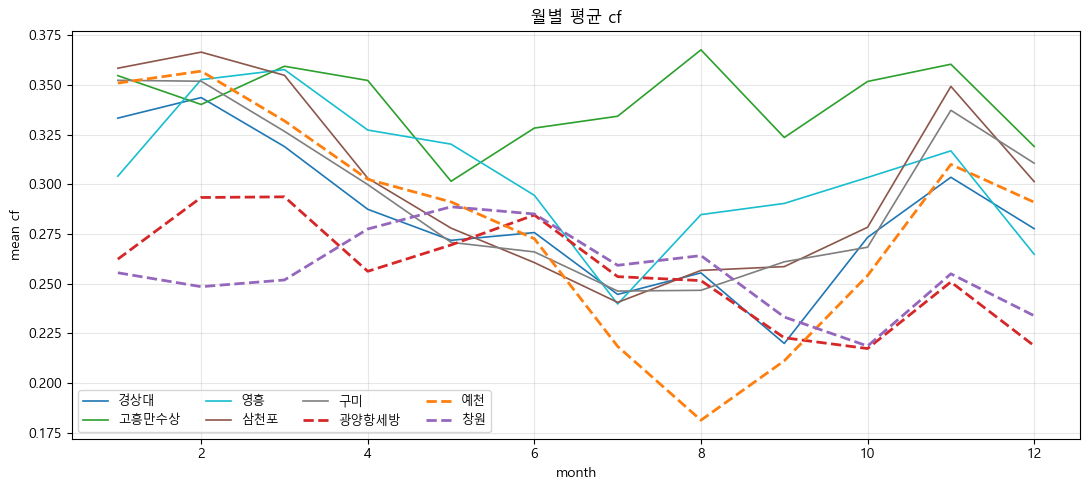

In [ ]:
month_avg = df[df.zenith_center < 85].groupby(['site', 'month'])['cf'].mean().unstack('site')
fig, ax = plt.subplots(figsize=(11, 5))
for site in ALL:
    ls = '--' if site in PROBLEM else '-'
    lw = 2.0 if site in PROBLEM else 1.2
    ax.plot(month_avg.index, month_avg[site], color=COLOR[site], ls=ls, lw=lw, label=site)
ax.set_xlabel('month'); ax.set_ylabel('mean cf'); ax.grid(alpha=0.3)
ax.set_title('월별 평균 cf')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()


→ **모델 함의**:
- PROBLEM 사이트의 계절 패턴이 다르면 (예: 여름에 더 떨어짐) → 적설·결로·온도·shading 같은 모델 미입력 변수 영향.
- 시계열로 단조 감소 → panel degradation 또는 partial outage 누적.


## 5. DSR_mean → cf 관계 — clear-sky 효율 곡선

같은 일사량(DSR)에서 cf가 어떻게 응답하는지.
**판독 기준**:
- 정상: cf ≈ k × DSR (linear, k는 site별 effective conversion)
- PROBLEM 사이트의 slope이 낮으면 → 작은 사이트 / panel underutilized / dust
- 같은 slope이지만 noise가 크면 → measurement / metering 문제


C:\Users\brave\AppData\Local\Temp\ipykernel_18340\332615605.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['bin'] = pd.cut(sub['dsr_mean'], bins)
C:\Users\brave\AppData\Local\Temp\ipykernel_18340\332615605.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['bin'] = pd.cut(sub['dsr_mean'], bins)
C:\Users\brave\AppData\Local\Temp\ipykernel_18340\332615605.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

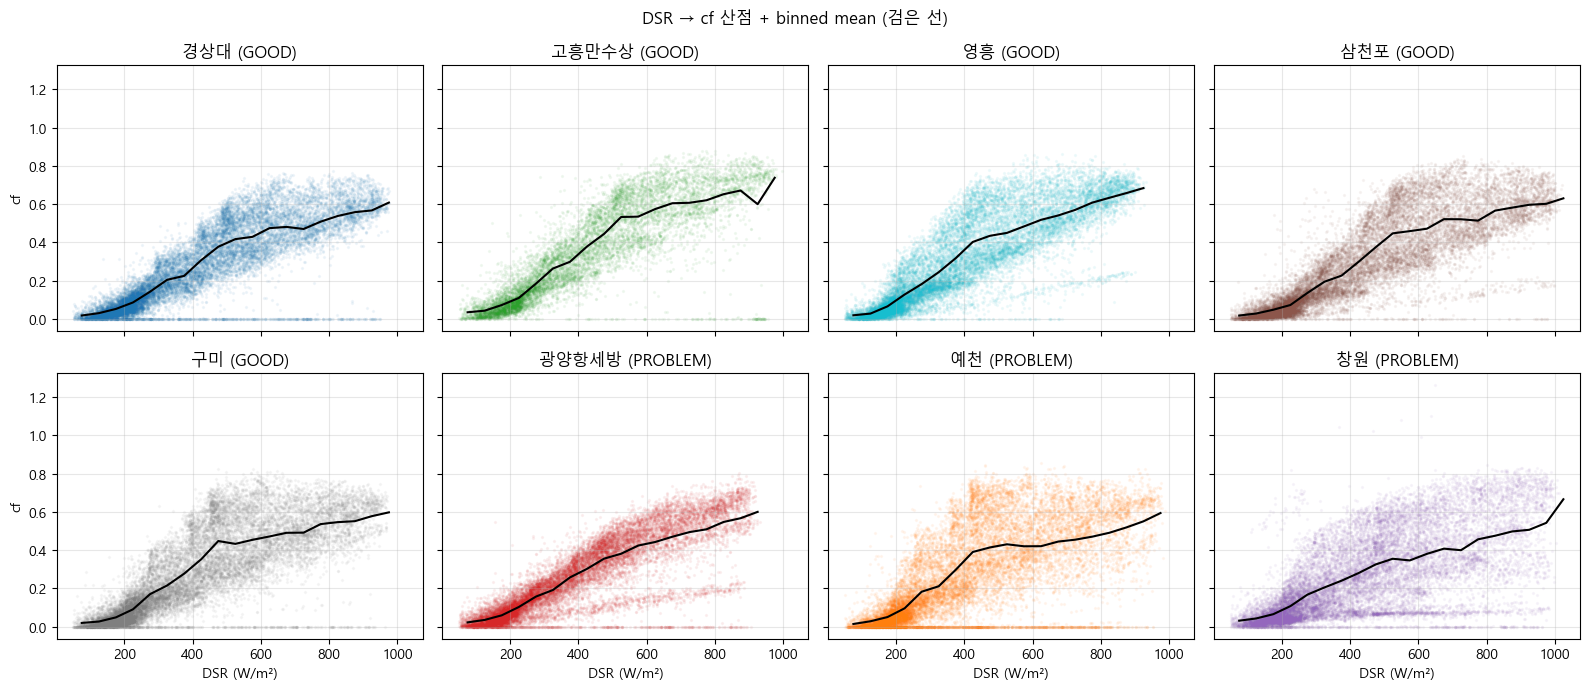


DSR > 200 영역 OLS slope (cf per W/m²) — clear-sky 효율 비교:
  [GOOD   ] 경상대        slope=0.746 (1e-3 cf/(W/m²))  intercept=-0.038  n=13,530
  [GOOD   ] 고흥만수상      slope=0.876 (1e-3 cf/(W/m²))  intercept=-0.024  n=7,673
  [GOOD   ] 영흥         slope=0.839 (1e-3 cf/(W/m²))  intercept=-0.018  n=12,353
  [GOOD   ] 삼천포        slope=0.782 (1e-3 cf/(W/m²))  intercept=-0.051  n=13,632
  [GOOD   ] 구미         slope=0.741 (1e-3 cf/(W/m²))  intercept=-0.009  n=13,302
  [PROBLEM] 광양항세방      slope=0.744 (1e-3 cf/(W/m²))  intercept=-0.034  n=12,394
  [PROBLEM] 예천         slope=0.635 (1e-3 cf/(W/m²))  intercept=+0.030  n=13,168
  [PROBLEM] 창원         slope=0.575 (1e-3 cf/(W/m²))  intercept=+0.015  n=13,546


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()
day = df[(df.zenith_center < 85) & (df.dsr_mean > 50)].copy()
for ax, site in zip(axes, ALL):
    sub = day[day.site == site]
    ax.scatter(sub['dsr_mean'], sub['cf'], s=2, alpha=0.05, color=COLOR[site])
    # binned mean
    bins = np.arange(0, 1100, 50)
    sub['bin'] = pd.cut(sub['dsr_mean'], bins)
    bm = sub.groupby('bin', observed=True)['cf'].mean()
    bm.index = [b.mid for b in bm.index]
    ax.plot(bm.index, bm.values, color='black', lw=1.5)
    grp = 'PROBLEM' if site in PROBLEM else 'GOOD'
    ax.set_title(f'{site} ({grp})')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('cf'); axes[4].set_ylabel('cf')
for i in range(4, 8): axes[i].set_xlabel('DSR (W/m²)')
plt.suptitle('DSR → cf 산점 + binned mean (검은 선)')
plt.tight_layout(); plt.show()

# slope 추정 (DSR>200 영역에서 OLS)
print('\nDSR > 200 영역 OLS slope (cf per W/m²) — clear-sky 효율 비교:')
slopes = {}
for site in ALL:
    sub = day[(day.site == site) & (day.dsr_mean > 200)]
    x = sub['dsr_mean'].values; y = sub['cf'].values
    if len(x) < 100: continue
    slope, intercept = np.polyfit(x, y, 1)
    slopes[site] = (slope, intercept, len(x))
    grp = 'PROBLEM' if site in PROBLEM else 'GOOD'
    print(f'  [{grp:7}] {site:<10} slope={slope*1000:.3f} (1e-3 cf/(W/m²))  '
          f'intercept={intercept:+.3f}  n={len(x):,}')


→ **모델 함의**:
- slope이 PROBLEM에서 낮으면 (예: GOOD 0.9e-3 vs PROBLEM 0.6e-3) → effective conversion 다름. 모델은 "DSR이 높으면 cf 높다" 학습하나, PROBLEM 사이트에서는 같은 DSR에 cf가 더 낮음 → over-prediction → 광양항세방 +7% bias 가설 부합.
- intercept 차이 → "DSR=0인데 cf>0" 또는 "DSR>0인데 cf=0"의 깊이.


## 6. Zenith → cf 관계 — 시간 의존성

PV는 zenith 작을수록(태양 높을수록) cf 높아야 정상.
**판독 기준**:
- PROBLEM에서 zenith=20° 정점 cf가 GOOD보다 낮으면 → underutilized.
- zenith 큰 영역(70~85°)에서 noise 차이 → 동/서 shading.


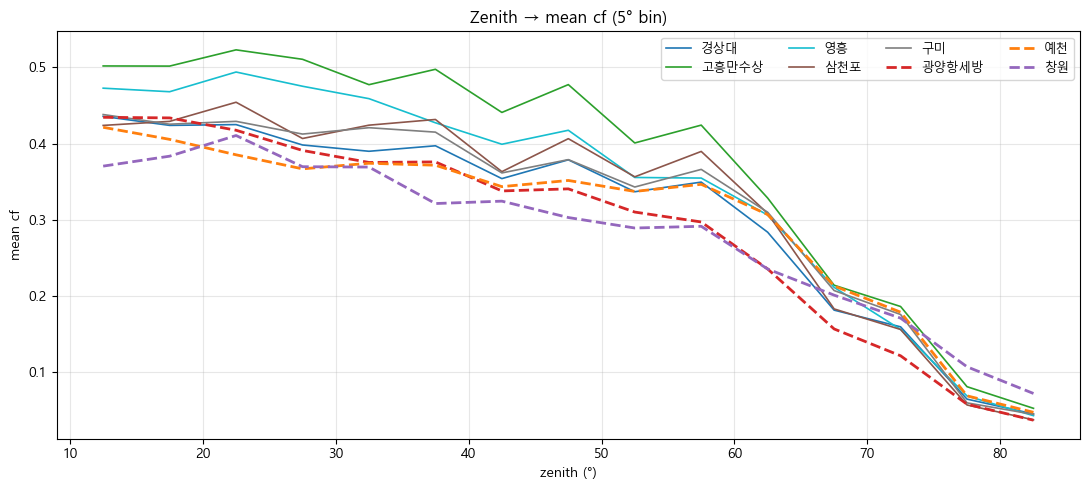

In [ ]:
bins = np.arange(0, 90, 5)
fig, ax = plt.subplots(figsize=(11, 5))
day_all = df[df.zenith_center < 85].copy()
day_all['zb'] = pd.cut(day_all['zenith_center'], bins)
for site in ALL:
    sub = day_all[day_all.site == site]
    bm = sub.groupby('zb', observed=True)['cf'].mean()
    centers = [b.mid for b in bm.index]
    ls = '--' if site in PROBLEM else '-'
    lw = 2.0 if site in PROBLEM else 1.2
    ax.plot(centers, bm.values, color=COLOR[site], ls=ls, lw=lw, label=site)
ax.set_xlabel('zenith (°)'); ax.set_ylabel('mean cf'); ax.grid(alpha=0.3)
ax.set_title('Zenith → mean cf (5° bin)')
ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()


→ **모델 함의**: 곡선 모양은 같은데 PROBLEM이 평행하게 아래로 내려가 있으면 → site-level efficiency offset (site_emb로도 잡힐 만한 신호인데, AdaLN site_oh가 이미 학습 시도 중). 곡선 형태 자체가 다르면 → 시간대별 shading.


## 7. dc10Tca (운량) → cf — 구름 응답

**판독 기준**:
- 정상: dc10Tca 0(맑음)에서 cf 높음, 10(흐림)에서 낮음
- PROBLEM에서 같은 dc10Tca에 cf scatter가 더 크면 → 운량 외 미입력 신호 (예: 안개·미세먼지·황사)


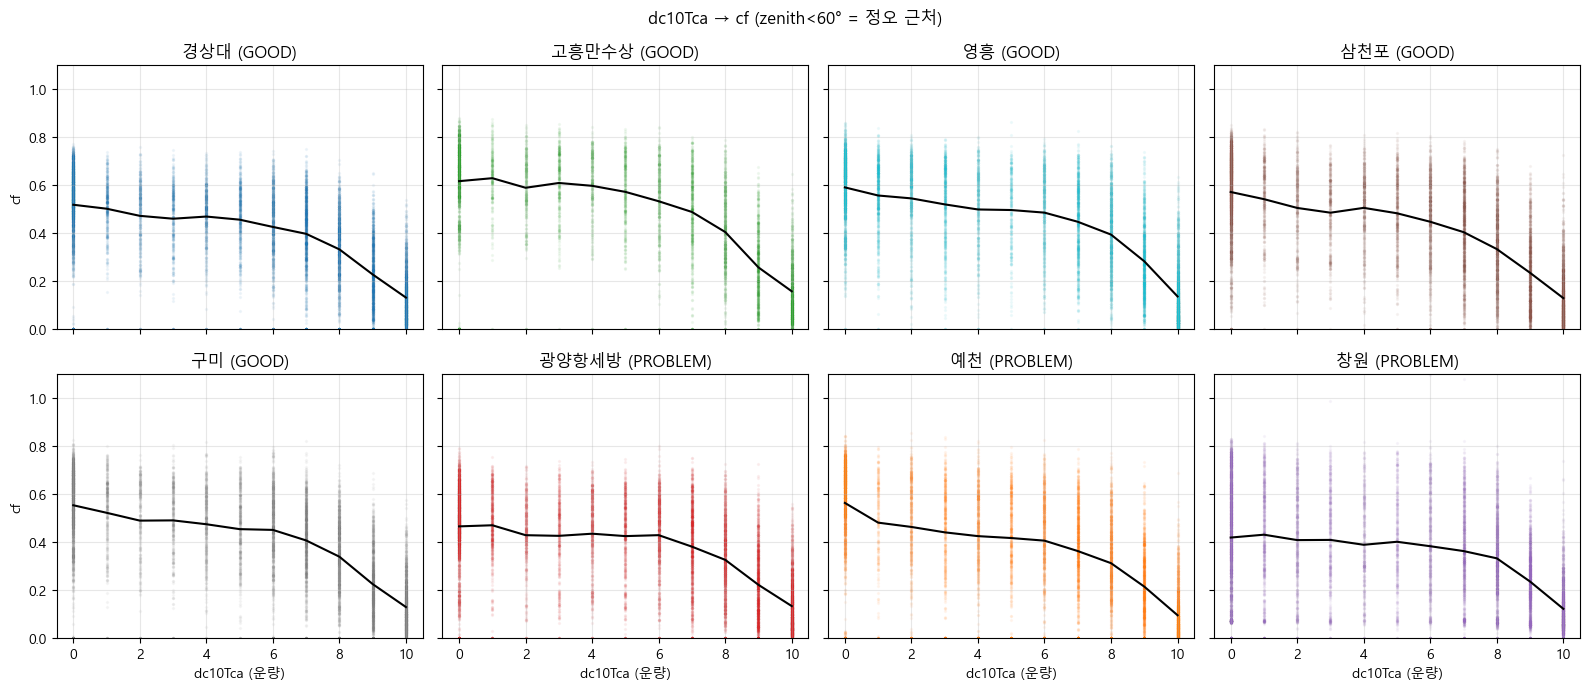

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
axes = axes.flatten()
day = df[(df.zenith_center < 60) & df.dc10Tca.notna()].copy()  # 정오 근처만 (zenith<60)
for ax, site in zip(axes, ALL):
    sub = day[day.site == site]
    ax.scatter(sub['dc10Tca'], sub['cf'], s=2, alpha=0.05, color=COLOR[site])
    # mean line
    bm = sub.groupby('dc10Tca')['cf'].mean()
    ax.plot(bm.index, bm.values, color='black', lw=1.5)
    grp = 'PROBLEM' if site in PROBLEM else 'GOOD'
    ax.set_title(f'{site} ({grp})')
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('cf'); axes[4].set_ylabel('cf')
for i in range(4, 8): axes[i].set_xlabel('dc10Tca (운량)')
plt.suptitle('dc10Tca → cf (zenith<60° = 정오 근처)')
plt.tight_layout(); plt.show()


→ **모델 함의**: PROBLEM에서 운량별 평균 곡선 형태가 다르면 → 같은 운량에 다른 일사량이 도착한다는 뜻. 단순 dc10Tca 한 변수론 부족 → 운형(상층운/하층운) 또는 광경로 정보 필요.


## 8. Anomaly: flatline / cluster / capacity violation

**Flatline**: cf가 N hour 연속 거의 동일한 비제로 값 → 정지·계측 stuck.
**Capacity violation**: cf > 1.05 → 분모(capacity) 잘못 또는 over-irradiance.
**Near-zero cluster**: 낮 시간(zenith<60)인데 cf < 0.05 → outage / shading.


In [ ]:
day = df[df.zenith_center < 60].copy()
day = day.sort_values(['site', 'datetime_kst']).reset_index(drop=True)
day['cf_diff'] = day.groupby('site')['cf'].diff().abs()

print('=== capacity violation (cf > 1.05, zenith<60°) ===')
viol = day[day.cf > 1.05].groupby('site').size().reindex(ALL, fill_value=0)
total = day.groupby('site').size().reindex(ALL, fill_value=1)
for s in ALL:
    grp = 'PROBLEM' if s in PROBLEM else 'GOOD'
    print(f'  [{grp:7}] {s:<10}  {viol[s]:>5} / {total[s]:>6}  ({viol[s]/total[s]*100:.2f}%)')

print('\n=== near-zero cluster (cf < 0.05, zenith<60°) ===')
near = day[day.cf < 0.05].groupby('site').size().reindex(ALL, fill_value=0)
for s in ALL:
    grp = 'PROBLEM' if s in PROBLEM else 'GOOD'
    print(f'  [{grp:7}] {s:<10}  {near[s]:>5} / {total[s]:>6}  ({near[s]/total[s]*100:.2f}%)')

print('\n=== flatline 의심 (3시간 연속 |Δcf|<0.005, cf>0.1) ===')
def count_flat(g):
    flat = (g['cf_diff'] < 0.005) & (g['cf'] > 0.1)
    # 3시간 연속
    rolling = flat.rolling(3, min_periods=3).sum()
    return (rolling == 3).sum()
flat = day.groupby('site').apply(count_flat).reindex(ALL, fill_value=0)
for s in ALL:
    grp = 'PROBLEM' if s in PROBLEM else 'GOOD'
    print(f'  [{grp:7}] {s:<10}  {flat[s]:>5} hr')


=== capacity violation (cf > 1.05, zenith<60°) ===
  [GOOD   ] 경상대             0 /   9379  (0.00%)
  [GOOD   ] 고흥만수상           0 /   5397  (0.00%)
  [GOOD   ] 영흥              0 /   8803  (0.00%)
  [GOOD   ] 삼천포             0 /   9471  (0.00%)
  [GOOD   ] 구미              0 /   9137  (0.00%)
  [PROBLEM] 광양항세방           0 /   9485  (0.00%)
  [PROBLEM] 예천              0 /   8985  (0.00%)
  [PROBLEM] 창원              3 /   9376  (0.03%)

=== near-zero cluster (cf < 0.05, zenith<60°) ===
  [GOOD   ] 경상대           810 /   9379  (8.64%)
  [GOOD   ] 고흥만수상         293 /   5397  (5.43%)
  [GOOD   ] 영흥            579 /   8803  (6.58%)
  [GOOD   ] 삼천포           642 /   9471  (6.78%)
  [GOOD   ] 구미            678 /   9137  (7.42%)
  [PROBLEM] 광양항세방         833 /   9485  (8.78%)
  [PROBLEM] 예천           1351 /   8985  (15.04%)
  [PROBLEM] 창원            627 /   9376  (6.69%)

=== flatline 의심 (3시간 연속 |Δcf|<0.005, cf>0.1) ===
  [GOOD   ] 경상대             0 hr
  [GOOD   ] 고흥만수상           0 hr
  [GOOD   ] 영

C:\Users\brave\AppData\Local\Temp\ipykernel_18340\2956203597.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flat = day.groupby('site').apply(count_flat).reindex(ALL, fill_value=0)


→ **모델 함의**:
- 특정 사이트만 capacity violation 다수 → capacity 분모 오류 → 학습 데이터 자체의 라벨 노이즈.
- near-zero cluster가 PROBLEM에서 많으면 → outage·shading이 모델 입력에 없는데 cf만 떨어짐 → 모델이 이걸 normal과 구분 못 함 → 평균 NMAE 악화.
- flatline 다수 → metering 문제. 학습/검증 모두에 있으면 모델 학습은 그대로 진행되나 진실값 자체가 의심됨.


## 9. 결측 대체(imputation) 비율

훈련 코드에서 결측 ta/hm/ws/dc10Tca를 site median으로 대체. 이 비율이 사이트별로 다르면 → 모델이 입력 노이즈를 다르게 받음.


In [ ]:
raw = pd.read_parquet(ROOT / 'data/processed/training_set.parquet')
raw = raw[raw.dsr_mean.notna() & raw.cf.notna()].copy()
miss = raw.groupby('site')[['ta','hm','ws','dc10Tca','rn']].apply(lambda g: g.isna().mean())
miss = miss.reindex(ALL).round(3)
miss['group'] = miss.index.map(lambda s: 'PROBLEM' if s in PROBLEM else 'GOOD')
print(miss.to_string())


          ta     hm     ws  dc10Tca     rn    group
site                                               
경상대    0.002  0.002  0.002    0.002  0.908     GOOD
고흥만수상  0.000  0.000  0.000    0.000  0.907     GOOD
영흥     0.000  0.000  0.000    0.000  0.889     GOOD
삼천포    0.002  0.002  0.002    0.002  0.908     GOOD
구미     0.001  0.002  0.002    0.002  0.893     GOOD
광양항세방  0.000  0.000  0.001    0.001  0.903  PROBLEM
예천     0.000  0.000  0.000    0.000  0.908  PROBLEM
창원     0.000  0.000  0.000    0.000  0.894  PROBLEM


→ **모델 함의**: PROBLEM 사이트의 결측률이 GOOD보다 크게 높으면 → 입력 noise가 많아 학습이 불안정. median imputation으로 정보가 손실됨.


## 10. Clear-day vs Partial-cloud subset 비교

**Clear**: dc10Tca ≤ 2 (운량 0~2/10)
**Partial**: 3 ≤ dc10Tca ≤ 7

각 subset에서 PROBLEM의 NMAE-like deviation을 직접 비교 — 데이터 품질 문제(맑은 날에도 다름)인지, 변동성 문제(흐린 날에만 다름)인지 구분.


In [ ]:
# clear-sky efficiency: cf vs dsr 정점 ratio (DSR>500, dc10Tca<=2)
clear = df[(df.zenith_center < 60) & (df.dc10Tca <= 2) & (df.dsr_mean > 500)].copy()
partial = df[(df.zenith_center < 60) & (df.dc10Tca >= 3) & (df.dc10Tca <= 7)].copy()

print('=== Clear day subset (dsr>500, dc<=2, zenith<60) ===')
print(f"  {'group':<7} {'site':<10} {'n':>6} {'mean cf':>8} {'std cf':>8} {'cf/dsr ratio':>14}")
for s in ALL:
    sub = clear[clear.site == s]
    if len(sub) < 50:
        print(f"  [{('PROBLEM' if s in PROBLEM else 'GOOD'):7}] {s:<10} too few"); continue
    grp = 'PROBLEM' if s in PROBLEM else 'GOOD'
    ratio = (sub['cf'] / sub['dsr_mean']).median() * 1000
    print(f"  [{grp:7}] {s:<10} {len(sub):>6} {sub['cf'].mean():>8.3f} {sub['cf'].std():>8.3f} {ratio:>13.3f}e-3")

print('\n=== Partial-cloud subset (dc 3~7, zenith<60) ===')
print(f"  {'group':<7} {'site':<10} {'n':>6} {'mean cf':>8} {'std cf':>8} {'cv':>6}")
for s in ALL:
    sub = partial[partial.site == s]
    if len(sub) < 50:
        print(f"  [{('PROBLEM' if s in PROBLEM else 'GOOD'):7}] {s:<10} too few"); continue
    grp = 'PROBLEM' if s in PROBLEM else 'GOOD'
    cv = sub['cf'].std() / sub['cf'].mean() if sub['cf'].mean() > 0 else 0
    print(f"  [{grp:7}] {s:<10} {len(sub):>6} {sub['cf'].mean():>8.3f} {sub['cf'].std():>8.3f} {cv:>6.3f}")


=== Clear day subset (dsr>500, dc<=2, zenith<60) ===
  group   site            n  mean cf   std cf   cf/dsr ratio
  [GOOD   ] 경상대          2786    0.517    0.158         0.792e-3
  [GOOD   ] 고흥만수상        1609    0.620    0.163         0.916e-3
  [GOOD   ] 영흥           2222    0.594    0.137         0.856e-3
  [GOOD   ] 삼천포          2952    0.566    0.158         0.796e-3
  [GOOD   ] 구미           2346    0.543    0.161         0.780e-3
  [PROBLEM] 광양항세방        2275    0.487    0.168         0.792e-3
  [PROBLEM] 예천           1953    0.536    0.190         0.797e-3
  [PROBLEM] 창원           2908    0.427    0.226         0.615e-3

=== Partial-cloud subset (dc 3~7, zenith<60) ===
  group   site            n  mean cf   std cf     cv
  [GOOD   ] 경상대          2803    0.432    0.156  0.360
  [GOOD   ] 고흥만수상        1648    0.551    0.169  0.307
  [GOOD   ] 영흥           2400    0.486    0.170  0.351
  [GOOD   ] 삼천포          2822    0.453    0.172  0.380
  [GOOD   ] 구미           2860    0.447    0

→ **모델 함의**:
- **Clear에서 cf/dsr ratio가 PROBLEM에서 GOOD보다 낮으면** → 데이터/설비 문제 (capacity over-estimate, soiling, derating). 모델이 못 잡는 문제 아님 — *타깃 자체*가 낮은 효율.
- **Partial에서 cv(변동계수)가 PROBLEM에서 크면** → 그 사이트가 microclimate (해양·산악 cloud burst) 더 심함. 모델 입력 보강(고해상도 위성, lead/lag) 필요.
- **둘 다 비슷하면** → 사이트 자체는 정상, 모델이 capacity 작은 사이트에 noise를 학습 못 잡고 있을 뿐.


## 11. 최종 진단 체크리스트

각 PROBLEM 사이트에 대해, 위 섹션의 어떤 시그널이 가장 강했는지 표시:

| 사이트 | clipping | flatline | cf/dsr 낮음 | 결측 다 | partial cv↑ | 결론(가설) |
|---|---|---|---|---|---|---|
| 광양항세방 | ? | ? | ? | ? | ? | ? |
| 예천 | ? | ? | ? | ? | ? | ? |
| 창원 | ? | ? | ? | ? | ? | ? |

**의사결정 분기**:
1. **데이터 품질 (capacity 잘못, flatline, missing 다수)** → preprocessing 수정 / 해당 행 제외 / capacity 재계산. 모델 변경 불필요.
2. **운영/설비 (작은 사이트 noise, soiling)** → site별 weight 조정 또는 robust loss (Huber). 모델 구조는 그대로.
3. **진짜 microclimate / shading** → 입력 보강 (위성 고해상도, 지형 PVGIS clear-sky, 해양 fog index). 그래도 안 되면 site별 specialist head.

**다음 액션**: 위 분석 후 PROBLEM 사이트별 가장 강한 시그널을 메모하고, 그에 맞는 처치를 plan에 추가한 뒤 재학습.
